In [3]:
! pip install wordcloud

In [4]:
import pandas as pd
import numpy as np
import re
import string
import nltk
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from textblob import TextBlob
from nltk.corpus import stopwords
from collections import Counter

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/samurai/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [5]:
comments = [
    "Absolutely loved the new smartphone! Camera quality is outstanding.",
    "Worst customer service ever. No response for my complaint.",
    "The battery life is amazing and lasts all day.",
    "Delivery was delayed by five days. Very disappointed.",
    "Excellent product at a reasonable price.",
    "The app crashes every time I open it.",
    "Great performance and smooth user experience.",
    "The update introduced too many bugs.",
    "I highly recommend this product to everyone.",
    "Waste of money. It stopped working in a week.",
    "Packaging was premium and secure.",
    "Customer support solved my issue quickly.",
    "Very poor build quality.",
    "The new interface is clean and modern.",
    "The product exceeded my expectations.",
    "Terrible delivery experience.",
    "Fast shipping and great discounts.",
    "Not satisfied with the battery performance.",
    "Excellent sound quality and beautiful design.",
    "The software needs serious improvements.",
    "Fantastic camera performance even at night.",
    "Price is slightly high but worth it.",
    "Good value for money.",
    "The screen quality is impressive.",
    "Very slow charging speed.",
    "Love the premium finish.",
    "The speaker volume is too low.",
    "Highly reliable and durable.",
    "Received a damaged product.",
    "Amazing customer support.",
    "Easy to install and configure.",
    "The application freezes frequently.",
    "Very happy with the purchase.",
    "Poor packaging but excellent quality.",
    "The features are innovative.",
    "Not worth the expensive price.",
    "Battery drains too quickly.",
    "Excellent display and smooth performance.",
    "The colors look vibrant.",
    "Bad software optimization.",
    "Everything works perfectly.",
    "The fingerprint sensor is slow.",
    "Awesome gaming performance.",
    "Very comfortable to use.",
    "The device heats up while charging.",
    "The latest update fixed many issues.",
    "Customer support never answered my emails.",
    "Excellent build quality.",
    "Highly recommended for students.",
    "Overall, a fantastic experience."
]

df = pd.DataFrame({"Comment": comments})

print(df.head())

                                             Comment
0  Absolutely loved the new smartphone! Camera qu...
1  Worst customer service ever. No response for m...
2     The battery life is amazing and lasts all day.
3  Delivery was delayed by five days. Very disapp...
4           Excellent product at a reasonable price.


Text preprocessing

In [6]:
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"@\w+", "", text)

    text = re.sub(r"#\w+", "", text)

    text = text.translate(str.maketrans('', '', string.punctuation))

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df["Cleaned"] = df["Comment"].apply(clean_text)

print(df.head())

                                             Comment  \
0  Absolutely loved the new smartphone! Camera qu...   
1  Worst customer service ever. No response for m...   
2     The battery life is amazing and lasts all day.   
3  Delivery was delayed by five days. Very disapp...   
4           Excellent product at a reasonable price.   

                                             Cleaned  
0  absolutely loved new smartphone camera quality...  
1     worst customer service ever response complaint  
2                     battery life amazing lasts day  
3            delivery delayed five days disappointed  
4                 excellent product reasonable price  


Senitement anlayis

In [7]:
def sentiment(text):

    score = TextBlob(text).sentiment.polarity

    if score > 0.2:
        return "Positive"

    elif score < -0.2:
        return "Negative"

    else:
        return "Neutral"

df["Sentiment"] = df["Cleaned"].apply(sentiment)

print(df.head())

                                             Comment  \
0  Absolutely loved the new smartphone! Camera qu...   
1  Worst customer service ever. No response for m...   
2     The battery life is amazing and lasts all day.   
3  Delivery was delayed by five days. Very disapp...   
4           Excellent product at a reasonable price.   

                                             Cleaned Sentiment  
0  absolutely loved new smartphone camera quality...  Positive  
1     worst customer service ever response complaint  Negative  
2                     battery life amazing lasts day  Positive  
3            delivery delayed five days disappointed  Negative  
4                 excellent product reasonable price  Positive  


Senitiment diatribution

In [8]:
sentiment_counts = df["Sentiment"].value_counts()

print(sentiment_counts)

Sentiment
Positive    28
Neutral     14
Negative     8
Name: count, dtype: int64


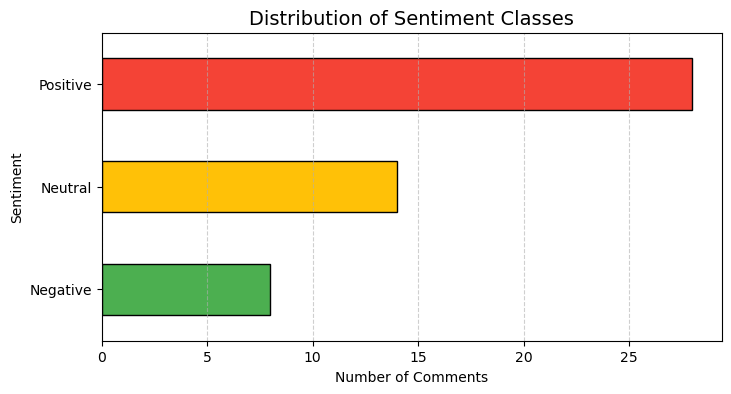

In [9]:
plt.figure(figsize=(8, 4))

sentiment_counts.sort_values().plot(
    kind='barh',
    color=['#4CAF50', '#FFC107', '#F44336'],
    edgecolor='black'
)

plt.title("Distribution of Sentiment Classes", fontsize=14)
plt.xlabel("Number of Comments")
plt.ylabel("Sentiment")
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.show()

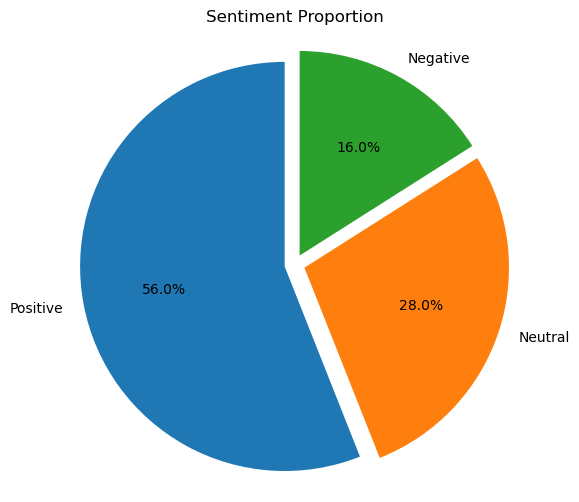

In [10]:
plt.figure(figsize=(6, 6))

plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    explode=[0.05]*len(sentiment_counts)
)

plt.title("Sentiment Proportion")
plt.axis('equal')

plt.show()

In [11]:

all_words = " ".join(df["Cleaned"])

words = all_words.split()

counter = Counter(words)

top_words = counter.most_common(15)

trend_df = pd.DataFrame(top_words,
                        columns=["Word","Frequency"])

print(trend_df)

           Word  Frequency
0       quality          6
1     excellent          5
2   performance          5
3      customer          4
4       product          4
5       battery          3
6         price          3
7    experience          3
8        highly          3
9       support          3
10          new          2
11       camera          2
12      amazing          2
13     delivery          2
14        great          2


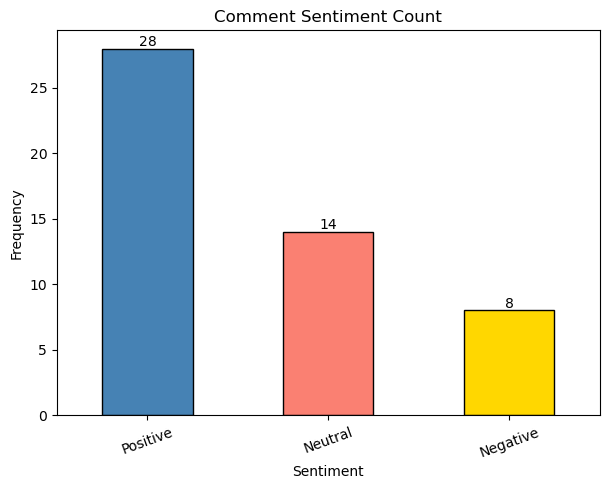

In [12]:
ax = sentiment_counts.plot(
    kind='bar',
    figsize=(7,5),
    color=['steelblue', 'salmon', 'gold'],
    edgecolor='black'
)

plt.title("Comment Sentiment Count")
plt.xlabel("Sentiment")
plt.ylabel("Frequency")
plt.xticks(rotation=20)

for p in ax.patches:
    ax.annotate(
        str(int(p.get_height())),
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.show()

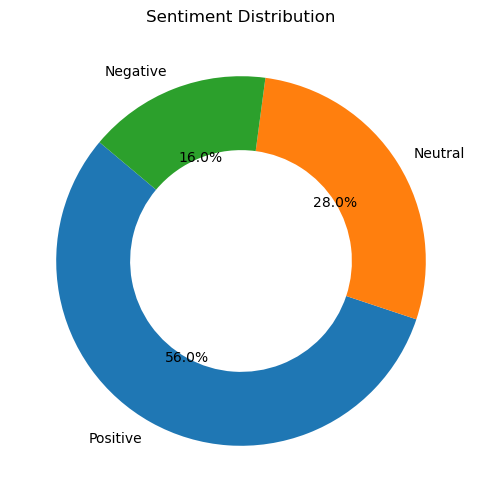

In [13]:
plt.figure(figsize=(6,6))

plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops=dict(width=0.4)
)

plt.title("Sentiment Distribution")
plt.show()

In [14]:
df["Polarity"] = df["Cleaned"].apply(
    lambda x: TextBlob(x).sentiment.polarity
)

print("Average Sentiment Score:", round(df["Polarity"].mean(),3))

Average Sentiment Score: 0.239
